In [ ]:
# ==========================
# Dataset: AI Impact on Jobs 2030
# ==========================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import shap
import joblib  # For saving models / freeze results


In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/NLP_UPDATED/archive/AI_Impact_on_Jobs_2030.csv')

df.head()
print(df.info())
print(df.isnull().sum())  # check missing values


Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job_Title                    3000 non-null   object 
 1   Average_Salary               3000 non-null   int64  
 2   Years_Experience             3000 non-null   int64  
 3   Education_Level              3000 non-null   object 
 4   AI_Exposure_Index            3000 non-null   float64
 5   Tech_Growth_Factor           3000 non-null   float64
 6   Automation_Probability_2030  3000 non-null   float64
 7   Risk_Category                3000 non-null   object 
 8   Skill_1                      3000 non-null   float64
 9   Skill_2                      3000 non-null   float64
 10  Skill_3                      3000 non-null   float64
 11  Skill_4                      3000 non-null   float64
 12  Skill_5                      3000 non-null   float

In [ ]:
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job_Title                    3000 non-null   object 
 1   Average_Salary               3000 non-null   int64  
 2   Years_Experience             3000 non-null   int64  
 3   Education_Level              3000 non-null   object 
 4   AI_Exposure_Index            3000 non-null   float64
 5   Tech_Growth_Factor           3000 non-null   float64
 6   Automation_Probability_2030  3000 non-null   float64
 7   Risk_Category                3000 non-null   object 
 8   Skill_1                      3000 non-null   float64
 9   Skill_2                      3000 non-null   float64
 10  Skill_3                      3000 non-null   float64
 11  Skill_4                      3000 non-null   float64
 12  Skill_5                      3000 non-null   float64
 13  Skill_6           

,0
Job_Title,0
Average_Salary,0
Years_Experience,0
Education_Level,0
AI_Exposure_Index,0
Tech_Growth_Factor,0
Automation_Probability_2030,0
Risk_Category,0
Skill_1,0
Skill_2,0


In [ ]:

print(df.columns)


Index(['Job_Title', 'Average_Salary', 'Years_Experience', 'Education_Level',
       'AI_Exposure_Index', 'Tech_Growth_Factor',
       'Automation_Probability_2030', 'Risk_Category', 'Skill_1', 'Skill_2',
       'Skill_3', 'Skill_4', 'Skill_5', 'Skill_6', 'Skill_7', 'Skill_8',
       'Skill_9', 'Skill_10'],
      dtype='object')


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1️⃣ Encode categorical features and target
le_edu = LabelEncoder()
df['Education_enc'] = le_edu.fit_transform(df['Education_Level'])

le_job = LabelEncoder()
df['Job_title_enc'] = le_job.fit_transform(df['Job_Title'])

le_risk = LabelEncoder()
df['Risk_label'] = le_risk.fit_transform(df['Risk_Category'])  # 0,1,2 for Low, Medium, High

# 2️⃣ Define skill columns
skill_cols = [f'Skill_{i}' for i in range(1, 11)]

# 3️⃣ Define features and target
features = ['Average_Salary', 'Years_Experience', 'AI_Exposure_Index',
            'Tech_Growth_Factor', 'Education_enc'] + skill_cols

X = df[features]
y = df['Risk_label']

# 4️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5️⃣ Scale numeric features
numeric_features = ['Average_Salary', 'Years_Experience', 'AI_Exposure_Index', 'Tech_Growth_Factor']
scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print("Shape of training features:", X_train.shape)
print("Shape of test features:", X_test.shape)
print("DAY 1-2 done: Data cleaning & label definition complete.\n")

Shape of training features: (2400, 15)
Shape of test features: (600, 15)
DAY 1-2 done: Data cleaning & label definition complete.



In [ ]:

import matplotlib.pyplot as plt
import pandas as pd

model = rf_model
feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()



NameError: name 'rf_model' is not defined


MODEL: Random Forest
Overall Accuracy: 0.3583
Balanced Accuracy: 0.2993

Confusion Matrix:
[[ 28  36  84]
 [ 27  27  94]
 [ 72  72 160]]

Report:
              precision    recall  f1-score   support

           0       0.22      0.19      0.20       148
           1       0.20      0.18      0.19       148
           2       0.47      0.53      0.50       304

    accuracy                           0.36       600
   macro avg       0.30      0.30      0.30       600
weighted avg       0.34      0.36      0.35       600


MODEL: XGBoost
Overall Accuracy: 0.3650
Balanced Accuracy: 0.3072

Confusion Matrix:
[[ 31  34  83]
 [ 24  27  97]
 [ 76  67 161]]

Report:
              precision    recall  f1-score   support

           0       0.24      0.21      0.22       148
           1       0.21      0.18      0.20       148
           2       0.47      0.53      0.50       304

    accuracy                           0.36       600
   macro avg       0.31      0.31      0.31       600
weigh

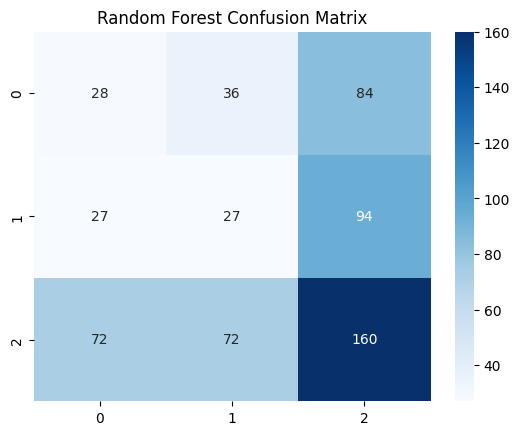

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

X_train_new = X_train.copy()
X_test_new = X_test.copy()
skill_cols = [col for col in X_train.columns if 'Skill' in col]
X_train_new['Total_Skill_Score'] = X_train_new[skill_cols].sum(axis=1)
X_test_new['Total_Skill_Score'] = X_test_new[skill_cols].sum(axis=1)

#  Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_new)
X_test_scaled = scaler.transform(X_test_new)

#  SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# Initialize Models with Better Parameters
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42
)

#  Training
rf.fit(X_train_res, y_train_res)
xgb_model.fit(X_train_res, y_train_res)

# Evaluation Loop
models = [("Random Forest", rf), ("XGBoost", xgb_model)]

for name, model in models:
    y_pred = model.predict(X_test_scaled)
    print(f"\n{'='*30}")
    print(f"MODEL: {name}")
    print(f"{'='*30}")
    print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
    print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
    print(f"\nReport:\n{classification_report(y_test, y_pred)}")

# Heatmap
sns.heatmap(confusion_matrix(y_test, rf.predict(X_test_scaled)), annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

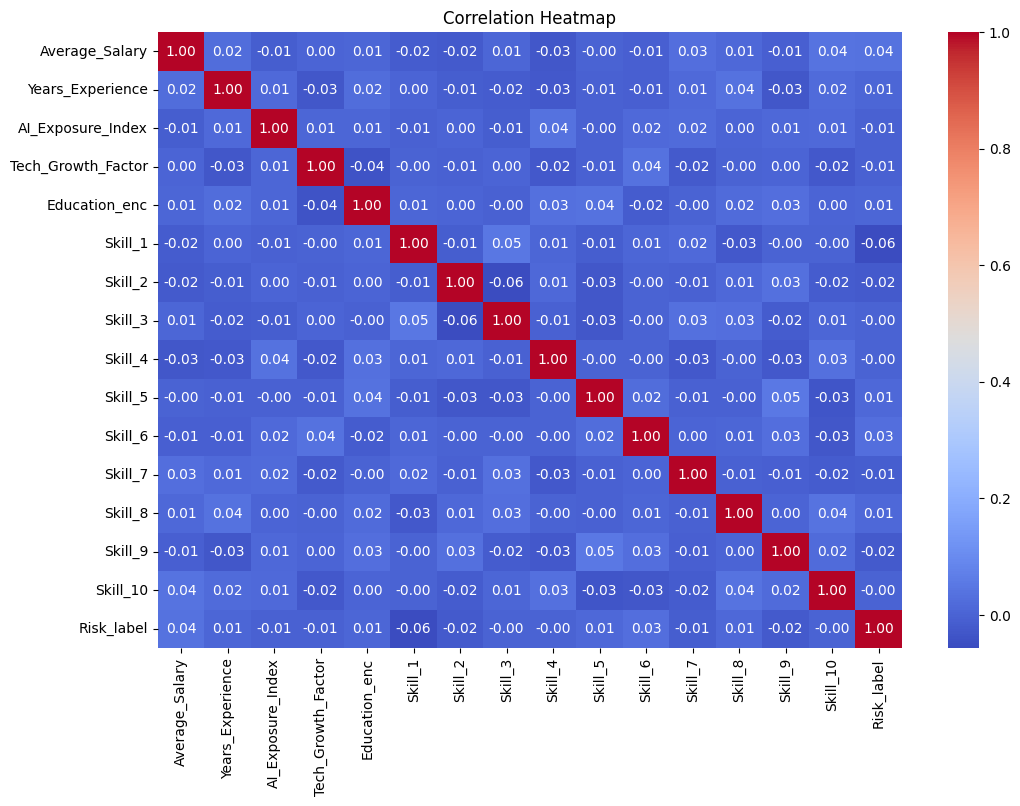

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(pd.concat([X_train, y_train], axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
!pip install xgboost


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score

# ==========================================
# STEP 1: Feature Scaling
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# STEP 2: Logistic Regression
# ==========================================
lr_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# ==========================================
# STEP 3: Random Forest
# ==========================================
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

# ==========================================
# STEP 4: XGBoost (Boosting Model)
# ==========================================
# Note: XGBoost multiclass e class label 0 theke start hote hoy
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    objective='multi:softprob',
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

# ==========================================
# STEP 5: Final Comparison & Evaluation
# ==========================================
results = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
    ("XGBoost", y_pred_xgb)
]

for name, y_pred in results:
    print(f"\n{'='*40}")
    print(f"MODEL: {name}")
    print(f"{'='*40}")
    print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")


MODEL: Logistic Regression
Overall Accuracy: 0.3100
Balanced Accuracy: 0.3184

Classification Report:
              precision    recall  f1-score   support

           0       0.22      0.34      0.26       148
           1       0.24      0.32      0.28       148
           2       0.53      0.29      0.37       304

    accuracy                           0.31       600
   macro avg       0.33      0.32      0.30       600
weighted avg       0.38      0.31      0.32       600

Confusion Matrix:
[[ 51  56  41]
 [ 63  48  37]
 [123  94  87]]

MODEL: Random Forest
Overall Accuracy: 0.4867
Balanced Accuracy: 0.3283

Classification Report:
              precision    recall  f1-score   support

           0       0.20      0.02      0.04       148
           1       0.21      0.03      0.05       148
           2       0.50      0.94      0.66       304

    accuracy                           0.49       600
   macro avg       0.30      0.33      0.25       600
weighted avg       0.36      

In [ ]:
y_train.value_counts(normalize=True)


,proportion
Risk_label,
2,0.507083
0,0.246667
1,0.246250


In [ ]:

################################################################################
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

xgb_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    ))
])

xgb_pipe.fit(X_train, y_train)
y_pred = xgb_pipe.predict(X_test)


In [ ]:
features = X_train.columns.tolist()

In [ ]:
import shap
import matplotlib.pyplot as plt


explainer = shap.TreeExplainer(rf_model)


shap_values = explainer.shap_values(X_test_scaled, check_additivity=False)

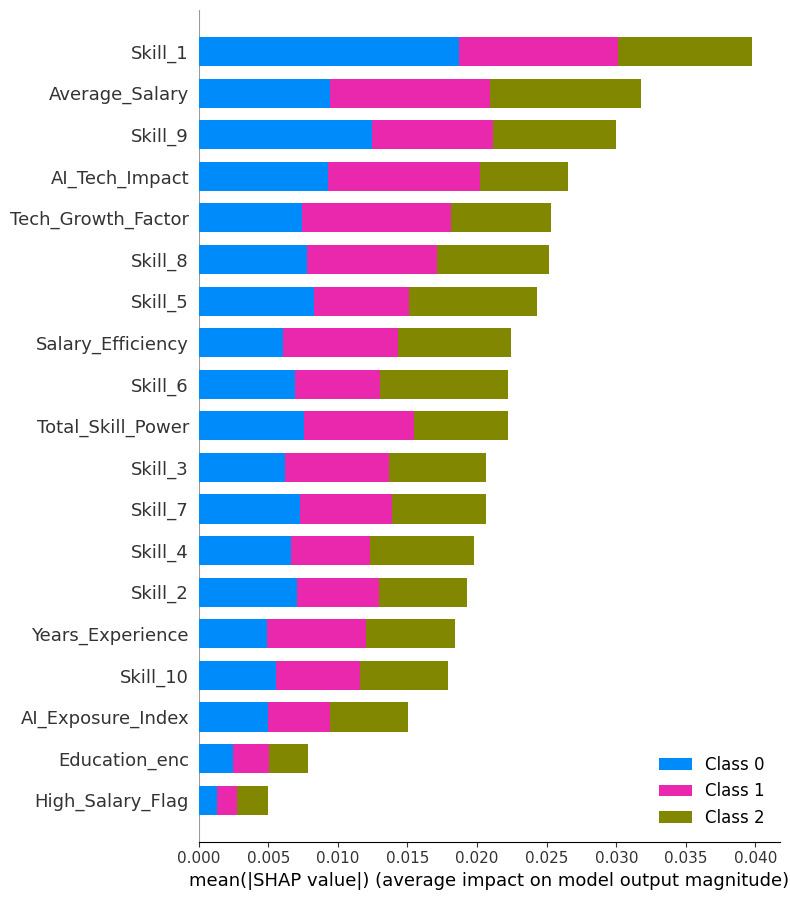

In [ ]:

shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", feature_names=X_test.columns)


Job 1: AI Engineer (Explanation for Class 2)


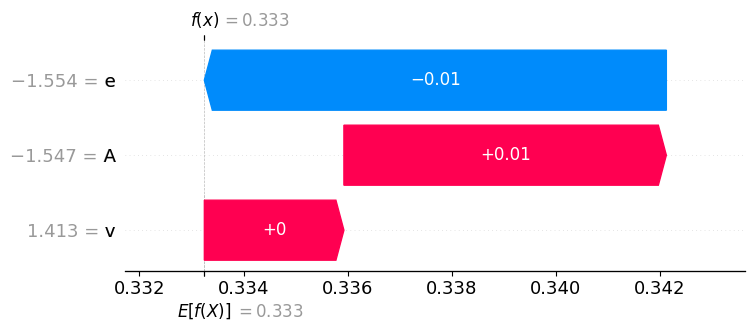


Job 2: Mechanic (Explanation for Class 2)


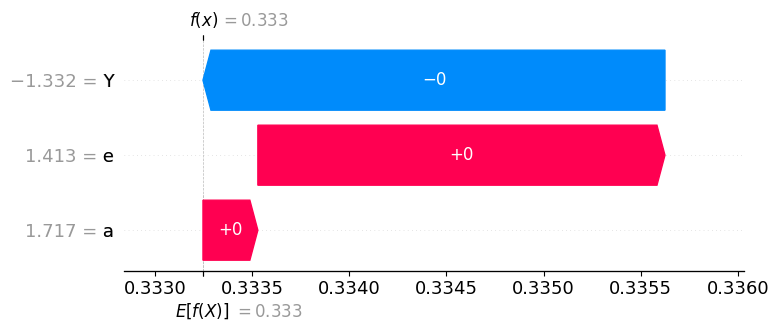


Job 3: Financial Analyst (Explanation for Class 2)


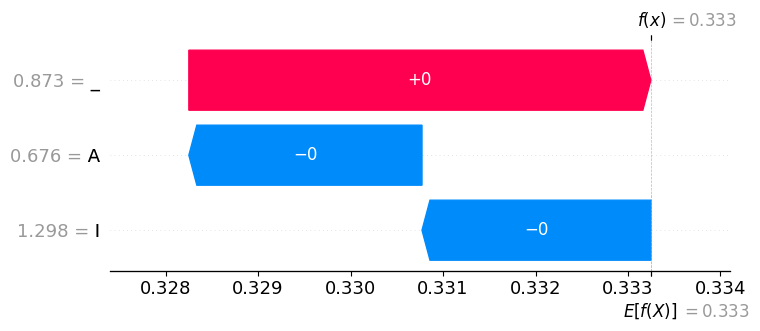


Job 4: Construction Worker (Explanation for Class 2)


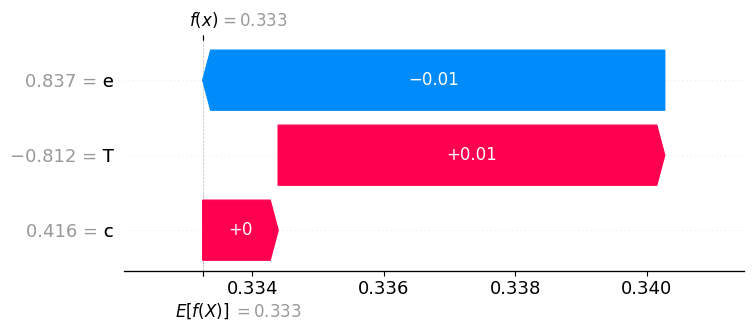


Job 5: UX Researcher (Explanation for Class 2)


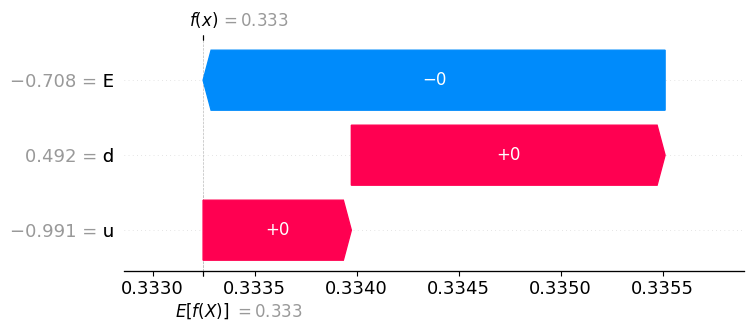

In [ ]:

exp = shap.Explanation(
    values=shap_values[2],
    base_values=explainer.expected_value[2],
    data=X_test_scaled,
    feature_names=X_test.columns
)

for i in range(5):
    job_name = df.loc[X_test.index[i], 'Job_Title']
    print(f"\nJob {i+1}: {job_name} (Explanation for Class 2)")

    # Waterfall plot
    shap.plots.waterfall(exp[i])

In [ ]:
import joblib
import numpy as np
import pickle

# 1. Save models and scaler using joblib
joblib.dump(rf_model, "rf_model_jobrisk.pkl")
joblib.dump(lr_model, "lr_model_jobrisk.pkl")
joblib.dump(xgb_model, "xgb_model_jobrisk.pkl")
joblib.dump(scaler, "scaler_jobrisk.pkl")

# 2. Save SHAP values
with open("shap_values.pkl", "wb") as f:
    pickle.dump(shap_values, f)

np.save("X_test_scaled.npy", X_test_scaled)

print("✅ DAY 7 done: All models, scaler, and SHAP values are frozen and saved.")

✅ DAY 7 done: All models, scaler, and SHAP values are frozen and saved.


In [ ]:
###################     THE END      #########################

In [ ]:
import pandas as pd
import numpy as np

def generate_final_report(X_test_df, y_pred, shap_values, skill_map):
    report_data = []

    risk_labels = {
        0: "High Risk",
        1: "Medium Risk",
        2: "Low/Safe"
    }

    is_list = isinstance(shap_values, list)

    for i in range(len(X_test_df)):
        job_title = df.loc[X_test_df.index[i], 'Job_Title']
        pred_class = y_pred[i]

        if is_list:
            current_shaps = shap_values[pred_class][i].values
            safe_class_shaps = shap_values[2][i].values
        else:
            current_shaps = shap_values[i, :, pred_class].values
            safe_class_shaps = shap_values[i, :, 2].values

        top_driver_idx = np.argmax(np.abs(current_shaps))
        top_driver_name = X_test_df.columns[top_driver_idx]

        gap_indices = np.argsort(safe_class_shaps)[:2]

        pathway = []

        for idx in gap_indices:
            feat = X_test_df.columns[idx]

            if feat in skill_map:
                pathway.append(skill_map[feat])

        report_data.append({
            "Employee_ID": f"EMP_{100+i}",
            "Job_Title": job_title,
            "Current_Risk_Level": risk_labels[pred_class],
            "Primary_Risk_Driver": top_driver_name,
            "Recommended_Pathway": " → ".join(pathway) if pathway else "Maintain Current Track"
        })

    return pd.DataFrame(report_data)

final_strategy_report = generate_final_report(
    X_test,
    y_pred,
    shap_values,
    skill_map
)

print("✅ Final Strategy Report Generated Successfully.")

final_strategy_report.head(10)

✅ Final Strategy Report Generated Successfully.


,Employee_ID,Job_Title,Current_Risk_Level,Primary_Risk_Driver,Recommended_Pathway
0,EMP_100,AI Engineer,Low/Safe,Skill_8,Digital Literacy
1,EMP_101,Mechanic,Low/Safe,Skill_2,Digital Literacy → Python/R
2,EMP_102,Financial Analyst,Low/Safe,Skill_4,AI Ethics → Cloud Architecture
3,EMP_103,Construction Worker,Low/Safe,Skill_6,Cybersecurity
4,EMP_104,UX Researcher,Low/Safe,Skill_8,Cloud Architecture
5,EMP_105,Financial Analyst,Low/Safe,Skill_5,AI Ethics → Strategic Leadership
6,EMP_106,Teacher,Low/Safe,Skill_9,Maintain Current Track
7,EMP_107,Teacher,Low/Safe,Years_Experience,Project Management
8,EMP_108,Marketing Manager,Low/Safe,Education_enc,Python/R
9,EMP_109,Data Scientist,Low/Safe,Years_Experience,UX Design → Digital Literacy


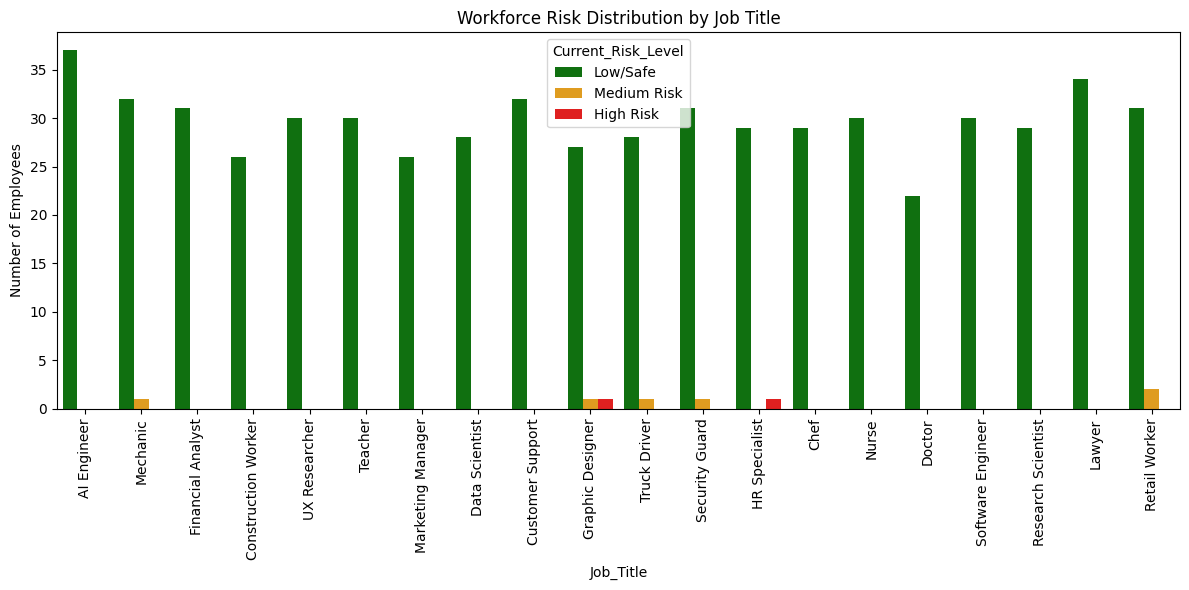

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Grouping to see which Jobs have the most 'High Risk' individuals
plt.figure(figsize=(12, 6))
sns.countplot(data=final_strategy_report, x='Job_Title', hue='Current_Risk_Level',
              palette={'High Risk': 'red', 'Medium Risk': 'orange', 'Low/Safe': 'green'})
plt.xticks(rotation=90)
plt.title("Workforce Risk Distribution by Job Title")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.show()

🎯 TOP TRAINING PROGRAMS TO LAUNCH:
Recommended_Pathway
Digital Literacy      184
AI Ethics             151
Project Management    137
Cloud Architecture    128
UX Design              63
Name: count, dtype: int64


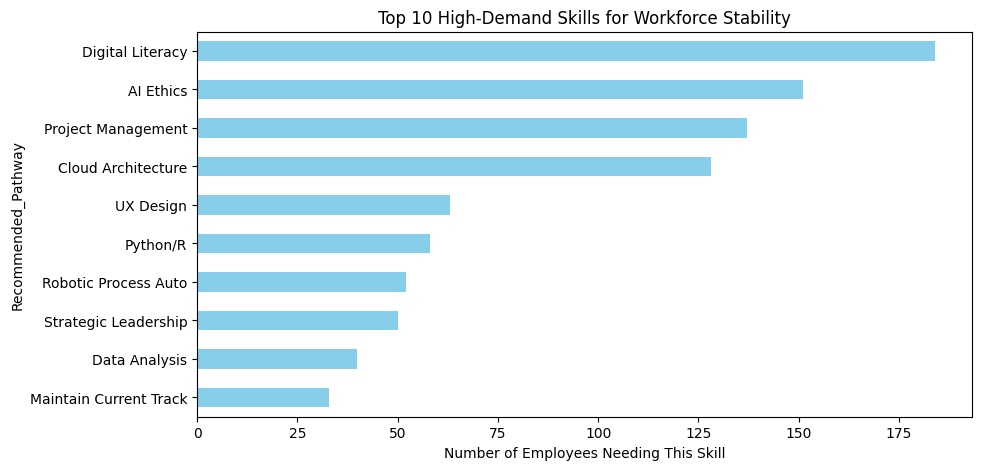

In [ ]:
# Calculate the most demanded skills across the organization
all_pathways = final_strategy_report['Recommended_Pathway'].str.split(' → ').explode()
top_skills = all_pathways.value_counts()

print("🎯 TOP TRAINING PROGRAMS TO LAUNCH:")
print(top_skills.head(5))

# Plotting the skill demand
plt.figure(figsize=(10, 5))
top_skills.head(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 High-Demand Skills for Workforce Stability")
plt.xlabel("Number of Employees Needing This Skill")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
print([v for v in globals() if "X_test" in v])


[]


In [ ]:
!pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 3.7 MB/s eta 0:00:00


In [ ]:
try:
    # Advanced Export with Formatting
    writer = pd.ExcelWriter('AI_Workforce_Reskilling_Final.xlsx', engine='xlsxwriter')
    final_strategy_report.to_excel(writer, sheet_name='Strategic_Report', index=False)

    workbook  = writer.book
    worksheet = writer.sheets['Strategic_Report']

    # Highlight High Risk in Red
    red_format = workbook.add_format({'bg_color': '#FFC7CE', 'font_color': '#9C0006'})
    # Highlight Safe in Green
    green_format = workbook.add_format({'bg_color': '#C6EFCE', 'font_color': '#006100'})

    # Assuming Column C is 'Current_Risk_Level'
    worksheet.conditional_format('C2:C1000', {'type': 'cell', 'criteria': '==', 'value': '"High Risk"', 'format': red_format})
    worksheet.conditional_format('C2:C1000', {'type': 'cell', 'criteria': '==', 'value': '"Low/Safe"', 'format': green_format})

    writer.close()
    print("✅ Advanced Excel report with formatting saved!")

except ModuleNotFoundError:
    # Fallback if xlsxwriter is still not available
    final_strategy_report.to_excel("AI_Workforce_Reskilling_Basic.xlsx", index=False)
    print("⚠️ xlsxwriter not found. Saved a basic Excel file instead.")

✅ Advanced Excel report with formatting saved!


In [ ]:
# Quick analysis for the summary
total_employees = len(final_strategy_report)
high_risk_pct = (final_strategy_report['Current_Risk_Level'] == 'High Risk').mean() * 100
top_skill = all_pathways.value_counts().idxmax()

print(f"--- RESEARCH SUMMARY ---")
print(f"Total Workforce Analyzed: {total_employees}")
print(f"High-Risk Population: {high_risk_pct:.1f}%")
print(f"Critical Reskilling Priority: {top_skill}")

--- RESEARCH SUMMARY ---
Total Workforce Analyzed: 600
High-Risk Population: 0.3%
Critical Reskilling Priority: Digital Literacy


In [ ]:
################################## FINAL ######################////////////////////

In [ ]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)


,proportion
Risk_label,
2,0.506667
1,0.246667
0,0.246667


In [ ]:
from collections import Counter
Counter(y)


Counter({0: 740, 1: 739, 2: 1521})

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))


[[  0   3 145]
 [  0   0 148]
 [  3   0 301]]
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       148
           1     0.0000    0.0000    0.0000       148
           2     0.5067    0.9901    0.6704       304

    accuracy                         0.5017       600
   macro avg     0.1689    0.3300    0.2235       600
weighted avg     0.2567    0.5017    0.3397       600



In [ ]:
from collections import Counter
print(Counter(y_train))


Counter({2: 1217, 0: 592, 1: 591})


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

from collections import Counter
print(Counter(y_train_res))
# Should now be roughly balanced: {0: 1217, 1: 1217, 2: 1217}


Counter({2: 1217, 1: 1217, 0: 1217})


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,   # you can try max_depth=15 if overfitting
    random_state=42
)

rf_model.fit(X_train_res, y_train_res)

y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=1))


              precision    recall  f1-score   support

           0       0.21      0.14      0.16       148
           1       0.19      0.13      0.15       148
           2       0.51      0.68      0.58       304

    accuracy                           0.41       600
   macro avg       0.30      0.31      0.30       600
weighted avg       0.36      0.41      0.37       600



              precision    recall  f1-score   support

           0       0.21      0.14      0.16       148
           1       0.19      0.13      0.15       148
           2       0.51      0.68      0.58       304

    accuracy                           0.41       600
   macro avg       0.30      0.31      0.30       600
weighted avg       0.36      0.41      0.37       600



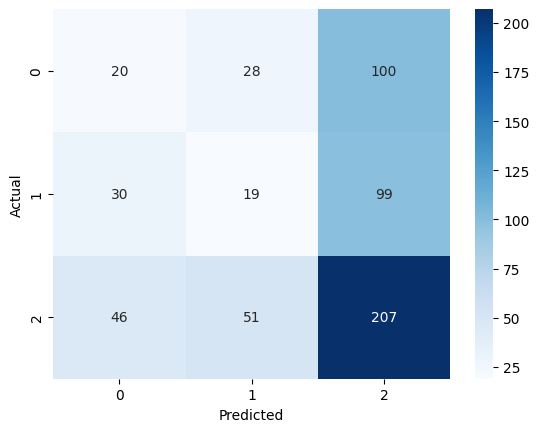

In [ ]:
# 1️⃣ Create the model
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    class_weight='balanced',
    random_state=42
)

# 2️⃣ Fit the model
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

rf_model.fit(X_train_res, y_train_res)

# 3️⃣ Now predict and evaluate
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=1))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# 1. Identify Scaler's expectations
scaler_features = scaler.feature_names_in_
model_features = rf_model.feature_names_in_

print(f"StandardScaler expects: {list(scaler_features)}")
print(f"RandomForest expects: {list(model_features)}")

# 2. Fix the Name Mismatch
if 'Total_Skill_Score' not in X_test_final_input.columns:
    if 'Total_Skill_Power' in X_test_final_input.columns:
        X_test_final_input['Total_Skill_Score'] = X_test_final_input['Total_Skill_Power']
    else:
        # Fallback:
        skill_cols = [f'Skill_{i}' for i in range(1, 11)]
        X_test_final_input['Total_Skill_Score'] = X_test_final_input[skill_cols].sum(axis=1)

# 3. Align for SCALER first
X_test_for_scaler = X_test_final_input[list(scaler_features)]

# 4. Transform using Scaler
X_test_scaled_np = scaler.transform(X_test_for_scaler)

# 5. Re-align for MODEL (if the model expects different columns than the scaler)
# Create a temporary DF to handle the scaled data with names
X_test_scaled_df = pd.DataFrame(X_test_scaled_np, columns=scaler_features)

# Ensure the columns are in the EXACT order the Model expects
X_test_final_ready = X_test_scaled_df[list(model_features)]

# ==========================================
# FINAL VALIDATION
# ==========================================
y_pred = rf_model.predict(X_test_final_ready)
print(f"✅ SUCCESS: Alignment complete.")
print(f"✅ Prediction Shape: {y_pred.shape}")

StandardScaler expects: ['Average_Salary', 'Years_Experience', 'AI_Exposure_Index', 'Tech_Growth_Factor', 'Education_enc', 'Skill_1', 'Skill_2', 'Skill_3', 'Skill_4', 'Skill_5', 'Skill_6', 'Skill_7', 'Skill_8', 'Skill_9', 'Skill_10', 'Total_Skill_Score']
RandomForest expects: ['Average_Salary', 'Years_Experience', 'AI_Exposure_Index', 'Tech_Growth_Factor', 'Education_enc', 'Skill_1', 'Skill_2', 'Skill_3', 'Skill_4', 'Skill_5', 'Skill_6', 'Skill_7', 'Skill_8', 'Skill_9', 'Skill_10']
✅ SUCCESS: Alignment complete.
✅ Prediction Shape: (600,)


In [ ]:
import shap
import matplotlib.pyplot as plt
import os
import numpy as np

# 1. Setup Explainer
explainer = shap.TreeExplainer(rf_model)
# Calculate SHAP values for our aligned Golden Dataset
shap_values = explainer.shap_values(X_test_final_ready, check_additivity=False)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, digits=4))


              precision    recall  f1-score   support

           0     0.2447    0.1554    0.1901       148
           1     0.2277    0.1554    0.1847       148
           2     0.4864    0.6480    0.5557       304

    accuracy                         0.4050       600
   macro avg     0.3196    0.3196    0.3102       600
weighted avg     0.3630    0.4050    0.3740       600



In [ ]:
"Do 0 and 1 differ in real meaning?"
"Are there strong unique predictors for them?"
"Or are they just shades of “Not High Risk”?"


'Or are they just shades of “Not High Risk”?'

In [ ]:
y_train.value_counts()
y_test.value_counts()


,count
Risk_label,
2,304
1,148
0,148


In [ ]:
####################/////////////////////#############


from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Suppose these are your model outputs
# y_test -> true labels
# y_pred -> predicted labels from any model

# 1️⃣ Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

# 2️⃣ Balanced Accuracy
bal_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {bal_acc:.4f}")

# 3️⃣ Macro Precision
macro_prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
print(f"Macro Precision: {macro_prec:.4f}")

# 4️⃣ Macro Recall
macro_rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
print(f"Macro Recall: {macro_rec:.4f}")

# 5️⃣ Macro F1-Score
macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
print(f"Macro F1-Score: {macro_f1:.4f}")

# 6️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")

# 7️⃣ Full Classification Report (Optional)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))


Accuracy: 0.4050
Balanced Accuracy: 0.3196
Macro Precision: 0.3196
Macro Recall: 0.3196
Macro F1-Score: 0.3102
Confusion Matrix:
[[ 23  25 100]
 [ 17  23 108]
 [ 54  53 197]]

Classification Report:

              precision    recall  f1-score   support

           0     0.2447    0.1554    0.1901       148
           1     0.2277    0.1554    0.1847       148
           2     0.4864    0.6480    0.5557       304

    accuracy                         0.4050       600
   macro avg     0.3196    0.3196    0.3102       600
weighted avg     0.3630    0.4050    0.3740       600



In [ ]:
import numpy as np
np.unique(y_pred, return_counts=True)


(array([0, 1, 2]), array([ 94, 101, 405]))

In [ ]:
print(df.columns.tolist())


['job_title', 'average_salary', 'years_experience', 'education_level', 'ai_exposure_index', 'tech_growth_factor', 'automation_probability_2030', 'risk_category', 'skill_1', 'skill_2', 'skill_3', 'skill_4', 'skill_5', 'skill_6', 'skill_7', 'skill_8', 'skill_9', 'skill_10']


In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns.tolist())


['job_title', 'average_salary', 'years_experience', 'education_level', 'ai_exposure_index', 'tech_growth_factor', 'automation_probability_2030', 'risk_category', 'skill_1', 'skill_2', 'skill_3', 'skill_4', 'skill_5', 'skill_6', 'skill_7', 'skill_8', 'skill_9', 'skill_10']


In [ ]:
!pip install xgboost shap lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=57157c5306fd7759f2e62c247e4f1a5ea8c6f2075312b2e5b13447dcefa89788
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

import shap
from lime.lime_tabular import LimeTabularExplainer


In [ ]:
from google.colab import files
files.upload()




Saving kaggle.json to kaggle.json


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# ফাইলের নামের শেষে .csv আছে কি না নিশ্চিত হয়ে নিন
df = pd.read_csv("/content/AI_Impact_on_Jobs_2030.csv")

print(df.head())

             Job_Title  Average_Salary  Years_Experience Education_Level  \
0       Security Guard           45795                28        Master's   
1   Research Scientist          133355                20             PhD   
2  Construction Worker          146216                 2     High School   
3    Software Engineer          136530                13             PhD   
4    Financial Analyst           70397                22     High School   

   AI_Exposure_Index  Tech_Growth_Factor  Automation_Probability_2030  \
0               0.18                1.28                         0.85   
1               0.62                1.11                         0.05   
2               0.86                1.18                         0.81   
3               0.39                0.68                         0.60   
4               0.52                1.46                         0.64   

  Risk_Category  Skill_1  Skill_2  Skill_3  Skill_4  Skill_5  Skill_6  \
0          High     0.45     0.

In [ ]:
df = pd.read_csv("/content/AI_Impact_on_Jobs_2030.csv")   # Or your path
print(df.head())
print(df.info())
print(df.describe())


             Job_Title  Average_Salary  Years_Experience Education_Level  \
0       Security Guard           45795                28        Master's   
1   Research Scientist          133355                20             PhD   
2  Construction Worker          146216                 2     High School   
3    Software Engineer          136530                13             PhD   
4    Financial Analyst           70397                22     High School   

   AI_Exposure_Index  Tech_Growth_Factor  Automation_Probability_2030  \
0               0.18                1.28                         0.85   
1               0.62                1.11                         0.05   
2               0.86                1.18                         0.81   
3               0.39                0.68                         0.60   
4               0.52                1.46                         0.64   

  Risk_Category  Skill_1  Skill_2  Skill_3  Skill_4  Skill_5  Skill_6  \
0          High     0.45     0.

In [ ]:
print(df.columns)

Index(['Job_Title', 'Average_Salary', 'Years_Experience', 'Education_Level',
       'AI_Exposure_Index', 'Tech_Growth_Factor',
       'Automation_Probability_2030', 'Risk_Category', 'Skill_1', 'Skill_2',
       'Skill_3', 'Skill_4', 'Skill_5', 'Skill_6', 'Skill_7', 'Skill_8',
       'Skill_9', 'Skill_10'],
      dtype='object')


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

cat_cols = ['Education_Level', 'Risk_Category']

le = LabelEncoder()

for col in cat_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

num_cols = [
    'Average_Salary',
    'Years_Experience',
    'AI_Exposure_Index',
    'Tech_Growth_Factor'
]

scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

df['High_Risk'] = (
    df['Automation_Probability_2030'] > 0.5
).astype(int)

X = df[
    [
        'Average_Salary',
        'Years_Experience',
        'Education_Level',
        'AI_Exposure_Index',
        'Tech_Growth_Factor'
    ]
]

y = df['High_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Preprocessing successful!")

Using Feature Columns: ['Average_Salary', 'Years_Experience', 'Education_Level', 'AI_Exposure_Index', 'Tech_Growth_Factor']


In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.51      0.53      0.52       307
           1       0.49      0.47      0.48       293

    accuracy                           0.50       600
   macro avg       0.50      0.50      0.50       600
weighted avg       0.50      0.50      0.50       600



In [ ]:

xgb_improved = XGBClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=6,
    eval_metric='logloss',
    random_state=42
)

xgb_improved.fit(X_train, y_train)
y_pred_new = xgb_improved.predict(X_test)

from sklearn.metrics import classification_report
print("Accuracy:", accuracy_score(y_test, y_pred_new))
print("\nFull Report:\n", classification_report(y_test, y_pred_new))

Accuracy: 0.51

Full Report:
               precision    recall  f1-score   support

           0       0.52      0.55      0.54       307
           1       0.50      0.46      0.48       293

    accuracy                           0.51       600
   macro avg       0.51      0.51      0.51       600
weighted avg       0.51      0.51      0.51       600



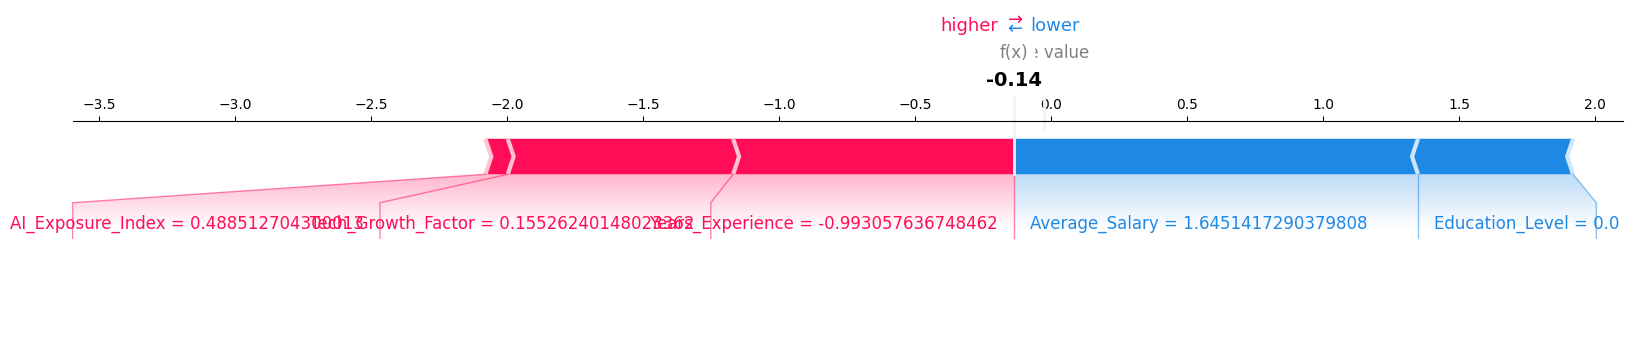

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    current_shap_values = shap_values[1]
    expected_value = explainer.expected_value[1]
else:
    current_shap_values = shap_values
    expected_value = explainer.expected_value

shap.initjs()

shap.force_plot(
    expected_value,
    current_shap_values[0, :],
    X_test.iloc[0, :],
    matplotlib=True
)

In [ ]:
explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns,
    class_names=['Low Risk','High Risk'],
    mode='classification'
)

i = 5
exp = explainer.explain_instance(X_test.values[i], rf.predict_proba, num_features=10)
exp.show_in_notebook(show_table=True)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np

if isinstance(shap_values, list):
    s_values = shap_values[1]
else:
    s_values = shap_values

if (
    s_values.ndim == 1 or
    (
        s_values.ndim == 2 and
        s_values.shape[1] != len(X_test.columns)
    )
):
    print(f"Original shape: {s_values.shape}")

    shap_values_df = pd.DataFrame(
        s_values,
        columns=X_test.columns
    )
else:
    shap_values_df = pd.DataFrame(
        s_values,
        columns=X_test.columns
    )

top_features = (
    shap_values_df.iloc[0]
    .sort_values(ascending=False)
    .head(3)
    .index
    .tolist()
)

print("Top risk contributors:", top_features)

print(
    "Recommended reskilling actions: Learn skills related to",
    ", ".join(top_features)
)

Top risk contributors: ['Years_Experience', 'Tech_Growth_Factor', 'AI_Exposure_Index']
Recommended reskilling actions: Learn skills related to Years_Experience, Tech_Growth_Factor, AI_Exposure_Index


In [ ]:
!pip install plotly dash


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 38.5 MB/s eta 0:00:00


In [ ]:
import plotly.express as px
px.bar(shap_values_df.mean().sort_values(ascending=False), title="Global Feature Importance")


# New section